In [1]:
import numpy as np
import pandas as pd

import scipy.stats as stats
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
%matplotlib inline
import seaborn as sns
sns.set_style("whitegrid")
import os
import geopandas as gpd
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.patches import Patch

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# Fig.9b

In [2]:
from itertools import cycle
import re

def clean_genelist(genelist):
    no_brackets = re.sub(r'\(.*?\)', '', genelist)
    #genes = [gene for gene in no_brackets.split(',') if not gene.startswith('LOC') and gene]
    genes = [gene for gene in no_brackets.split(',')]
    return ','.join(genes)
def manhattan_plot1(df, chr_col, loc_col, val_col, xlabel, ylabel, 
                   cutoff=None, highlight=None, annotation=None, ann_col=None, ylim=None, invert_yaxis=False, top_xaxis=False, ticklabelsize=12, figsize=(20, 4), axlabelsize=12, markersize=12):
    sns.set_theme(style="ticks")
    fig, ax = plt.subplots(1, 1, figsize=figsize)
#    offsets = {}
    loc_offset = 0
    xticks = []
    xticklabels = []
    for chrom, color in zip(df[chr_col].unique(), cycle(['#949597', '#D6D7D9'])):
#        offsets[chrom] = loc_offset
        tmpdf = df[df[chr_col]==chrom]
        tmpdf.loc[:, loc_col] += loc_offset
        xticklabels.append(chrom)
        xticks.append(tmpdf[loc_col].median())
        tmpdf.plot(kind='scatter', x=loc_col, y=val_col, ax=ax, s=markersize, color=color, marker='o', alpha=0.8)
        if isinstance(highlight, pd.DataFrame):
            hdf = highlight.loc[highlight[chr_col]==chrom, [loc_col, val_col, 'color']]
            if hdf.shape[0] > 0:
                hdf[loc_col] += loc_offset
                hdf.plot(kind='scatter', x=loc_col, y=val_col, ax=ax, s=markersize, color=hdf['color'], marker='o', alpha=0.8)
        if cutoff:
            #ax.hlines(cutoff[chrom], tmpdf[loc_col].values[0], tmpdf[loc_col].values[-1])
            ax.hlines(cutoff, tmpdf[loc_col].values[0], tmpdf[loc_col].values[-1], color='r', linestyle='--')
        if isinstance(annotation, pd.DataFrame):
            for index, row in annotation[annotation[chr_col]==chrom].iterrows():
                anndf = df[(df[chr_col]==chrom)&(df['BIN_START']>=row['BIN_START'])&(df['BIN_END']<=row['BIN_END'])]
                x, y = row[loc_col]+loc_offset, row[val_col]
                genes = row[ann_col]
                plt.plot([x, x], [y, y + 0.2], 'k--', linewidth=1, alpha=0.5)  # 虚线
                plt.text(x, y + 0.2, genes, fontsize=6, ha='center', va='bottom', fontstyle='italic', 
                         bbox=dict(facecolor='white', alpha=0.2, edgecolor='none', pad=0.2))
        loc_offset = tmpdf[loc_col].values[-1] # assume loc is sorted
        
    ax.set_xlabel(xlabel, fontsize=axlabelsize)
    ax.set_ylabel(ylabel, fontsize=axlabelsize)
    plt.xticks(xticks, xticklabels)
    ax.set_xlim([df[loc_col].values[0], tmpdf[loc_col].values[-1]])
    if ylim:
        ax.set_ylim(ylim)
    if invert_yaxis:
        ax.invert_yaxis()
    if top_xaxis:
        ax.xaxis.tick_top()
        ax.spines['right'].set_visible(False)
        ax.spines['bottom'].set_visible(False)
        ax.xaxis.set_label_position('top')
    else:
        ax.spines['right'].set_visible(False)
        ax.spines['top'].set_visible(False)
    for label in (ax.get_xticklabels() + ax.get_yticklabels()):
        label.set_fontsize(ticklabelsize)

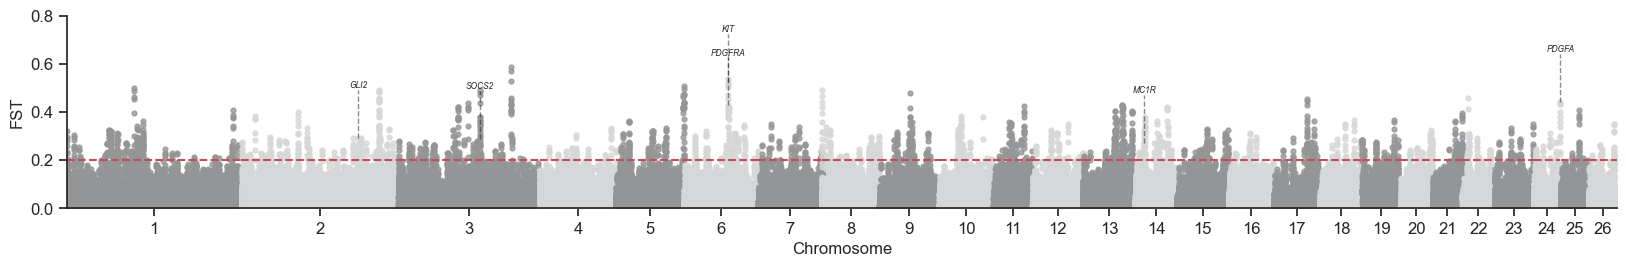

In [3]:
# --- 原始准备代码保持不变 ---

path = "./"
fst = pd.read_csv(f"{path}/neweurope_vs_oldeurope.all.fst", sep="\t")
fst = fst.sort_values(by=['CHROM', 'BIN_END'], ascending=[True, True])
fst_sel = pd.read_csv(f"{path}/neweurope_vs_oldeurope.all.fst.top.0.01.filter", sep="\t")
fst_cutoff = fst_sel['WEIGHTED_FST'].min()
fst_ann = pd.read_csv(f"{path}/neweurope_vs_oldeurope.all.fst.top.0.01.bed.anno", sep="\t")
fst_ann['ann'] = fst_ann['ann'].str.replace(r'gene-|\([^)]*\)', '', regex=True)
fst_ann['cleaned_ann'] = fst_ann['ann'].apply(clean_genelist)
fst_ann['split_cleaned_ann'] = fst_ann['cleaned_ann'].str.split(',')
fst_ann_explode = fst_ann.explode('split_cleaned_ann').reset_index(drop=True)

# 只保留每个基因最大FST值对应的注释行
max_fst_indices = fst_ann_explode.groupby('split_cleaned_ann')['WEIGHTED_FST'].idxmax()
fst_ann_explode_filter = fst_ann_explode.loc[max_fst_indices]

# 👉 指定要标注的基因
my_genes = [ 'KIT','GLI2','SOCS2','PDGFRA','MC1R','PDGFA','STK10','PPIH','CLDN16','THNSL2']

# 提取对应的注释信息用于标注
fst_ann_highlight = fst_ann_explode_filter[fst_ann_explode_filter['split_cleaned_ann'].isin(my_genes)]

# --- 绘制曼哈顿图（不使用 highlight，只做 annotation） ---
manhattan_plot1(
    fst, 'CHROM', 'BIN_END', 'WEIGHTED_FST',
    'Chromosome', 'FST',
    cutoff=fst_cutoff,
    annotation=fst_ann_highlight,
    ann_col='split_cleaned_ann',
    ylim=(0, 0.8),
    figsize=(20, 2.5)
)
ax = plt.gca()
for child in ax.get_children():
    if isinstance(child, plt.matplotlib.collections.PathCollection):
        child.set_rasterized(True)
#plt.savefig("manhattan_europe_onlyanno.2025.6.21.pdf", bbox_inches='tight',dpi=300)


# Fig. 9c

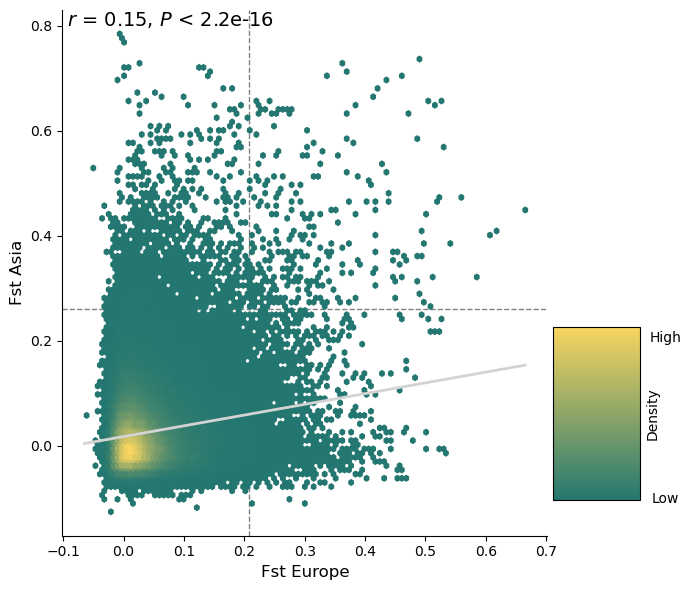

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, linregress
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

# 读取数据
df = pd.read_csv("all.fst", sep="\t")
df = df.dropna(subset=["Fst_Europe", "Fst_Asia"])

# 提取变量
x = df["Fst_Europe"]
y = df["Fst_Asia"]


# 计算 Pearson 相关系数和线性拟合
r, p = pearsonr(x, y)
slope, intercept, *_ = linregress(x, y)
x_threshold = np.percentile(x, 99)
y_threshold = np.percentile(y, 99)

# 创建自定义颜色映射
colors = [ "#237770", "#F8D560"]  # 蓝→绿→黄
custom_cmap = LinearSegmentedColormap.from_list("custom_gradient", colors)

# 创建图像
plt.figure(figsize=(7, 6))
plt.axvline(x_threshold, color='gray', linestyle='--', linewidth=1, zorder=0)
plt.axhline(y_threshold, color='gray', linestyle='--', linewidth=1, zorder=0)
# 绘制 hexbin 密度图（使用自定义颜色）
hb = plt.hexbin(x, y, gridsize=100, cmap=custom_cmap, mincnt=1, zorder=1)

# 调整颜色条位置和样式
cb = plt.colorbar(
    hb, 
    aspect=2, 
    pad=0.01,
    anchor=(0.0, 0.1)
)
cb.set_label("Density")
cb.set_ticks([])  # 隐藏数值刻度

# 调整High/Low标签位置（颜色与渐变两端对应）
cb.ax.text(1.3, 0.9, 'High', ha='center', va='bottom', 
           transform=cb.ax.transAxes, color='black')  # 黄色端
cb.ax.text(1.3, 0.05, 'Low', ha='center', va='top', 
           transform=cb.ax.transAxes, color='black')  # 蓝色端

# 添加回归线
x_vals = pd.Series(sorted(x))
plt.plot(x_vals, slope * x_vals + intercept, color='lightgray', linewidth=2)
# 计算 Fst 前 1% 阈值（即 99 分位数）


# 添加阈值虚线（横轴和纵轴）


# 处理 p 值显示
if p < 1e-16:
    p_str = "$P$ < 2.2e-16"
else:
    p_str = f"$P$ = {np.format_float_positional(p, precision=16, fractional=False, trim='-')}"

# 添加文字信息
plt.text(0.01, 1,
         f"$r$ = {r:.2f}, {p_str}",
         transform=plt.gca().transAxes,
         fontsize=14,
         verticalalignment='top')

# 坐标轴和标题
plt.xlabel("Fst Europe", fontsize=12)
plt.ylabel("Fst Asia", fontsize=12)

# 设置边框（仅显示左和下）
ax = plt.gca()
ax.spines['bottom'].set_visible(True)
ax.spines['left'].set_visible(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
# 美化布局
plt.tight_layout()
#plt.savefig("Fst_plot.5.27.pdf", dpi=300, bbox_inches='tight', transparent=True)
plt.show()

# Fig. 9d

In [ ]:



import numpy as np
import pandas as pd

import scipy.stats as stats
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
%matplotlib inline
import seaborn as sns
sns.set_style("whitegrid")
import os






In [ ]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.patches import Patch

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [ ]:
# 1. 读取文件
df_eur = pd.read_csv("europe.csv", sep=",")
df_asia = pd.read_csv("asia.csv", sep=",")

# 2. 筛选符合条件的行
df_eur_filtered = df_eur[(df_eur['Tissues with LFSR < 0.05'] == 1) & (df_eur['num_var'] > 500)]
df_asia_filtered = df_asia[(df_asia['Tissues with LFSR < 0.05'] == 1) & (df_asia['num_var'] > 500)]
eur_top = df_eur_filtered[df_eur_filtered['Annotation'] == '1%'][['Tissue', 'Odds ratio']].rename(columns={'Odds ratio': 'OR_EUR'})
asia_top = df_asia_filtered[df_asia_filtered['Annotation'] == '1%'][['Tissue', 'Odds ratio']].rename(columns={'Odds ratio': 'OR_ASIA'})
df_merged = pd.merge(eur_top, asia_top, on='Tissue')


In [ ]:
from scipy.stats import pearsonr

# 计算相关性
r, pval = pearsonr(df_merged['OR_EUR'], df_merged['OR_ASIA'])
print(f"Pearson r = {r:.3f}, p = {pval:.2e}")

Pearson r = 0.744, p = 9.49e-04


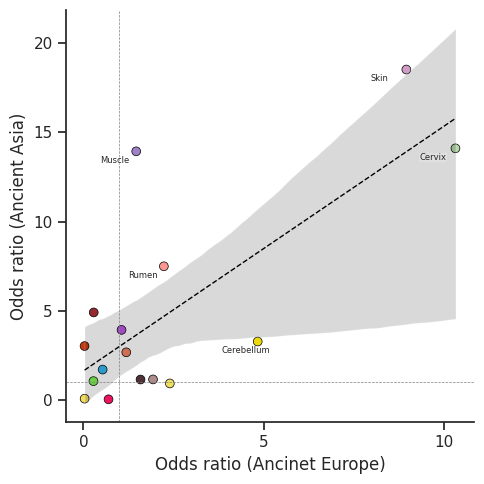

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# 1. 合并两个表格，按组织名
df_merged = pd.merge(eur_top, asia_top, on='Tissue')

# 2. 读取颜色映射
tisorder = pd.read_csv("/storage/public/home/2021050411/gtex/tissue.order", sep="\t")
palette = tisorder.set_index('Tissue (QTL)')['Color'].to_dict()

# 3. 计算 combined OR
df_merged['combined_OR'] = df_merged['OR_EUR'] * df_merged['OR_ASIA']

# 4. 计算 Pearson 相关性
r, pval = pearsonr(df_merged['OR_EUR'], df_merged['OR_ASIA'])

# 5. 画散点图
plt.figure(figsize=(5, 5))
sns.set_theme(style="ticks")

ax = sns.scatterplot(
    data=df_merged,
    x='OR_EUR', y='OR_ASIA',
    hue='Tissue',
    palette=palette,
    s=40,
    edgecolor='black'
)
sns.regplot(
    data=df_merged,
    x='OR_EUR', y='OR_ASIA',
    scatter=False,
    color='black',
    line_kws={'linestyle': 'dashed', 'linewidth': 1}
)

# 6. 标注 top5 tissue 名
top5 = df_merged.nlargest(5, 'combined_OR')
for _, row in top5.iterrows():
    tissue = ' '.join(row['Tissue'].split('_'))
    plt.text(row['OR_EUR']-1 , row['OR_ASIA'] -0.5, tissue,
             fontsize=6, va='center',
             bbox=dict(facecolor='white', alpha=0.2, edgecolor='none', pad=0.2))

# 7. 图形美化
plt.xlabel("Odds ratio (Ancinet Europe)")
plt.ylabel("Odds ratio (Ancient Asia)")
#plt.title("Top 1% Enriched Tissues: Europe vs Asia")
plt.axhline(1, linestyle='--', color='gray', linewidth=0.5)
plt.axvline(1, linestyle='--', color='gray', linewidth=0.5)

# 设置坐标轴范围一致

plt.xticks(range(0,11,5))
plt.yticks(range(0,21,5))
sns.despine()
plt.legend().remove()
plt.tight_layout()
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
# 保存图形为PDF文件
#plt.savefig('eur_asia_odds_ratio_scatterplot.info0.80.pdf', dpi=300, bbox_inches='tight')

plt.show()